# Isolation - GameAI

## Introduction

This Jupyter notebook illustrates the process of creation and testing of the ***minimax with alpha-beta pruning*** algorithm. The game (called Isolation) is defined in [this file](./two_player_games/games/isolation.py).

#### Algorithm Description

**MiniMax**  
The minimax algorithm is the core mechanic behind the AI for Isolation. It is based on the core concept of players always choosing the perfect moves. The decision, which move would be the most optimal, minimax recursively alternates between players, making the perfect decisions for both of them. This way, the AI always expects the enemy to make the perfect move and does not count on their mistakes, making it more effective.

**Alpha-Beta pruning**  
The Alpha-Beta pruning makes the MiniMax much faster and more efficient. It uses the information about the best moves that max and min can make (alpha - max's best guaranteed move, beta - min's). If alpha >= beta at any point, the branch can stop being explored, as a more optimal solution has already been found

#### Core Rules

The game begins with two players in opposite corners. It is turn-based - players alternate their moves and is played on a grid-based square map. In their turn, a player can move their character to an adjacent file (diagonals allowed). This marks the cell as theirs and renders it impossible to occupy until the end of the game for both players. The player, who is unable to move first loses the game.

#### Seeding

To keep the notebook consistent between launches, a seeding mechanism has been added, which makes the outcomes repeatable.

In [1]:
RANDOM_SEED = 23121

## Algorithm Implementation

First, we will define the `IsolationAI` class, which will be responsible for handling all the MiniMax elements (along with alpha-beta pruning). 

Our MiniMax has 2 different heuristic functions defined - the FULL and SIMPLE mode:
- SIMPLE is the easiest possible heuristic, it only considers the amount of moves that different players can perform at a given moment and returns that (unless the game will end, in which case it returns a very big/small score)
- FULL is the more advanced option. In addition to considering the amount of moves that players can perform, it also makes the algorithm consider, how close it is to the center.

Both of those heuristics will be used in the [Experiments](#experiments) section.

In [2]:
from two_player_games.player import Player
from typing import Optional
import math
import random
from two_player_games.games.isolation import Isolation, IsolationMove, IsolationState
from enum import Enum

class EvaluationFunction(Enum):
    FULL = "FULL"
    SIMPLE = "SIMPLE"

class IsolationAI:
    def __init__(self, player: Player, depth: int) -> None:
        self.player = player
        self.depth = depth

    def evaluate(self, state: IsolationState) -> float:
        if state.is_finished():
            winner = state.get_winner()
            if winner == self.player:
                return 10000
            elif winner is None:
                return 0
            else:
                return -10000

        player = self.player
        opponent = state.other_player if state.current_player == player else state.current_player

        player_moves = len(list(state.get_moves_for_player(self.player)))
        opponent_moves = len(list(state.get_moves_for_player(opponent)))

        player_pos = state.current_positions[self.player]
        opponent_pos = state.current_positions[opponent]

        def center_score(pos: int) -> float:
            row, col = pos // state.size, pos % state.size
            center = (state.size - 1) / 2
            return -((row - center)**2 + (col - center)**2)

        return (
            3 * (player_moves - opponent_moves)
            + .3 * (center_score(player_pos) - center_score(opponent_pos))
        )

    def evaluate_simple(self, state: IsolationState) -> float:
        if state.is_finished():
            winner = state.get_winner()
            if winner == self.player:
                return 1_000
            elif winner is None:
                return 0
            else:
                return -1_000

        player_moves = len(list(state.get_moves_for_player(self.player)))

        opponent = state.other_player if state.current_player == self.player else state.current_player
        opponent_moves = len(list(state.get_moves_for_player(opponent)))

        return 2 * player_moves - opponent_moves

    def minimax_with_pruning(
            self,
            state: IsolationState,
            depth: int,
            alpha: float,
            beta: float,
            evaluation_function: EvaluationFunction = EvaluationFunction.FULL
        ) -> tuple[float, Optional[IsolationMove]]:
        evaluate = self.evaluate if evaluation_function == EvaluationFunction.FULL else self.evaluate_simple
        if depth == 0 or state.is_finished():
            return evaluate(state), None

        is_max = (state.current_player == self.player)

        best_move = None
        best_val = -math.inf if is_max else math.inf

        moves = list(state.get_moves())

        for move in moves:
            new_state = state.make_move(move)

            val, _ = self.minimax_with_pruning(new_state, depth - 1, alpha, beta, evaluation_function)

            if is_max:
                if val > best_val:
                    best_val = val
                    best_move = move
                alpha = max(alpha, val)
            else:
                if val < best_val:
                    best_val = val
                    best_move = move
                beta = min(beta, val)

            if beta <= alpha:
                break

        return best_val, best_move

    def choose_move(self, state: IsolationState, evaluation_function: EvaluationFunction = EvaluationFunction.FULL) -> Optional[IsolationMove]:
        _, move = self.minimax_with_pruning(
            state=state,
            depth=self.depth,
            alpha=-math.inf,
            beta=math.inf,
            evaluation_function=evaluation_function
        )
        return move

Let's do a test run to see, if the AI can play against itself correctly.

In [3]:
from typing import cast

game = Isolation(size=3)
state = cast(IsolationState, game.state)
ai = IsolationAI(player=state.current_player, depth=5)

while not state.is_finished():
    print(state)
    move = ai.choose_move(state)
    if move:
        print(f"AI chooses: {move.field}")
        state = state.make_move(move)
print(state)


[O]| 1 | 2 
-----------
 3 | 4 | 5 
-----------
 6 | 7 |[X]

Current player: O
AI chooses: 4

 O | 1 | 2 
-----------
 3 |[O]| 5 
-----------
 6 | 7 |[X]

Current player: X
AI chooses: 5

 O | 1 | 2 
-----------
 3 |[O]|[X]
-----------
 6 | 7 | X 

Current player: O
AI chooses: 3

 O | 1 | 2 
-----------
[O]| O |[X]
-----------
 6 | 7 | X 

Current player: X
AI chooses: 1

 O |[X]| 2 
-----------
[O]| O | X 
-----------
 6 | 7 | X 

Current player: O
AI chooses: 6

 O |[X]| 2 
-----------
 O | O | X 
-----------
[O]| 7 | X 

Current player: X
AI chooses: 2

 O | X |[X]
-----------
 O | O | X 
-----------
[O]| 7 | X 

Current player: O
AI chooses: 7

 O | X |[X]
-----------
 O | O | X 
-----------
 O |[O]| X 

Winner: Player O


We have to define a runner class that will make it much easier to run games, both Player vs AI and AI vs AI

In [4]:
class IsolationRunner:
    def __init__(
        self,
        size: int = 5,
        human_player: Optional[Player] = None,
        ai_depth: Optional[int] = None,
        ai_depths: Optional[tuple[int, int]] = None,
        random_beginning: bool = False
    ):
        self.human_player = human_player
        self.ai1: Optional[IsolationAI] = None
        self.ai2: Optional[IsolationAI] = None

        # AI vs human
        if human_player and ai_depth is not None:
            ai_player = Player("X")
            first, second = human_player, ai_player

            self.ai1 = IsolationAI(ai_player, depth=ai_depth)

        # AI vs AI
        elif ai_depths is not None:
            depth1, depth2 = ai_depths

            first = Player("O")
            second = Player("X")

            self.ai1 = IsolationAI(first, depth=depth1)
            self.ai2 = IsolationAI(second, depth=depth2)

        else:
            first = Player("O")
            second = Player("X")

        # random swap
        if random_beginning and random.choice([True, False]):
            first, second = second, first

        self.first_player = first
        self.second_player = second

        self.game = Isolation(size=size, first_player=first, second_player=second)
        self.state = self.game.state

    def play(
        self,
        do_prints: bool = True,
        print_last: bool = False,
        evaluation_function: EvaluationFunction = EvaluationFunction.FULL,
        use_seed: Optional[int] = RANDOM_SEED
    ):
        if use_seed is not None:
            random.seed(use_seed)

        while not self.state.is_finished():
            if do_prints:
                print(self.state)

            assert isinstance(self.state, IsolationState)
            current_player = self.state.current_player
            move = None

            # human
            if self.human_player and current_player == self.human_player:
                moves = list(self.state.get_moves())
                while move not in moves:
                    inp = input(f"Available moves {[m.field for m in moves]}. Enter move for {current_player.char}: ")
                    try:
                        move_input = int(inp)
                        move = IsolationMove(move_input)
                        if move not in moves and do_prints:
                            print("Invalid move. Try again.")
                    except ValueError:
                        if "x" in str(inp):
                            return None
                        if do_prints:
                            print("Enter a valid number.")

            # ai1
            elif self.ai1 and current_player == self.ai1.player:
                move = self.ai1.choose_move(self.state, evaluation_function)
                assert move
                if do_prints:
                    print(f"AI1 (depth: {self.ai1.depth}) ({current_player.char}) chooses: {move.field}")

            # ai2
            elif self.ai2 and current_player == self.ai2.player:
                move = self.ai2.choose_move(self.state, evaluation_function)
                assert move
                if do_prints:
                    print(f"AI2 (depth: {self.ai2.depth}) ({current_player.char}) chooses: {move.field}")

            # human vs human
            else:
                moves = list(self.state.get_moves())
                while move not in moves:
                    inp = input(f"Available moves {[m.field for m in moves]}. Enter move for {current_player.char}: ")
                    try:
                        move_input = int(inp)
                        move = IsolationMove(move_input)
                        if move not in moves:
                            print("Invalid move. Try again.")
                    except ValueError:
                        if "x" in str(inp):
                            return None
                        print("Enter a valid number.")

            assert move
            self.state = self.state.make_move(move)

        if do_prints or print_last:
            print(self.state)

        winner = self.state.get_winner()

        if winner is None:
            return None
        if self.ai1 and winner == self.ai1.player:
            return self.ai1.depth
        if self.ai2 and winner == self.ai2.player:
            return self.ai2.depth
        if self.human_player:
            return 0 if winner == self.human_player else 1
        return None

Let's try launching the game against a real player.

In [5]:
human = Player("O")
runner = IsolationRunner(
    size=5,
    human_player=human,
    ai_depth=10
)
runner.play();


[O]| 1 | 2 | 3 | 4 
-------------------
 5 | 6 | 7 | 8 | 9 
-------------------
10 |11 |12 |13 |14 
-------------------
15 |16 |17 |18 |19 
-------------------
20 |21 |22 |23 |[X]

Current player: O

 O | 1 | 2 | 3 | 4 
-------------------
[O]| 6 | 7 | 8 | 9 
-------------------
10 |11 |12 |13 |14 
-------------------
15 |16 |17 |18 |19 
-------------------
20 |21 |22 |23 |[X]

Current player: X
AI1 (depth: 10) (X) chooses: 18

 O | 1 | 2 | 3 | 4 
-------------------
[O]| 6 | 7 | 8 | 9 
-------------------
10 |11 |12 |13 |14 
-------------------
15 |16 |17 |[X]|19 
-------------------
20 |21 |22 |23 | X 

Current player: O

 O | 1 | 2 | 3 | 4 
-------------------
 O | 6 | 7 | 8 | 9 
-------------------
10 |[O]|12 |13 |14 
-------------------
15 |16 |17 |[X]|19 
-------------------
20 |21 |22 |23 | X 

Current player: X
AI1 (depth: 10) (X) chooses: 12

 O | 1 | 2 | 3 | 4 
-------------------
 O | 6 | 7 | 8 | 9 
-------------------
10 |[O]|[X]|13 |14 
-------------------
15 |16 |17 | X 

Now, the first AI vs AI with different depths run will be launched. Let's try 2 vs 8 and see, if a higher depth performs better than a low one.

In [6]:
runner = IsolationRunner(
    size=6,
    ai_depths=(2, 8)
)
runner.play(False, True, EvaluationFunction.FULL);


 O | 1 | 2 | 3 | 4 | 5 
-----------------------
[X]| O | X | O | O |11 
-----------------------
 X | X | O | X | O |17 
-----------------------
 X |[O]| X | X | O |23 
-----------------------
 O | X | X | O | X |29 
-----------------------
30 | O | O |33 |34 | X 

Winner: Player X


## Experiments

To make running experiments much easier, `IsolationMultiSim` will be defined. It will allow for batch run processing. It will also have graphing capabilities to visualize the state of the match.

In [7]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class DuelResult:
    depth_pair: tuple[int, int]
    wins_ai1: int
    wins_ai2: int
    difference: int
    total_games: int

class IsolationMultiSim:
    def __init__(self, size: int = 5):
        self.size = size
        self.results: list[DuelResult] = []

    def run_duel(
        self,
        depth_pair: tuple[int, int],
        n_games: int = 50,
        random_beginning: bool = True,
        evaluation_function: EvaluationFunction = EvaluationFunction.FULL,
        use_seed: Optional[int] = RANDOM_SEED,
        print_last: bool = False
    ) -> DuelResult:
        if use_seed is not None:
            random.seed(use_seed)
        depth1, depth2 = depth_pair
        wins_ai1 = 0
        wins_ai2 = 0

        for _ in tqdm(range(n_games), desc=f"Depth {depth1} vs {depth2}"):
            runner = IsolationRunner(
                size=self.size,
                ai_depths=(depth1, depth2),
                random_beginning=random_beginning
            )
            result = runner.play(
                do_prints=False,
                print_last=print_last,
                evaluation_function=evaluation_function,
                use_seed=None
            )
            if result == depth1:
                wins_ai1 += 1
            elif result == depth2:
                wins_ai2 += 1

        duel_result = DuelResult(
            depth_pair,
            wins_ai1,
            wins_ai2,
            wins_ai1 - wins_ai2,
            wins_ai1 + wins_ai2
        )

        self.results.append(duel_result)
        return duel_result

    def plot_duel_result(self, duel_result: DuelResult, evaluation_function: EvaluationFunction = EvaluationFunction.FULL):
        depth1, depth2 = duel_result.depth_pair
        wins_ai1 = duel_result.wins_ai1
        wins_ai2 = duel_result.wins_ai2
        difference = duel_result.difference
        total_games = duel_result.total_games

        x = [0]
        _, ax = plt.subplots(figsize=(8, 6))

        ax.bar(x, [total_games], color="lightgray", alpha=0.3, label="Total games")
        ax.bar(x, [-total_games], color="lightgray", alpha=0.3)
        ax.bar(x, [wins_ai1], color="green", alpha=0.7, label="AI1 wins")
        ax.bar(x, [-wins_ai2], color="red", alpha=0.7, label="AI2 wins")
        ax.scatter(x, [difference], color="blue", s=120, zorder=5, label="Difference (AI1-AI2)")
        ax.set_xticks([0])
        ax.set_xticklabels([f"{depth1}v{depth2}"])
        ax.set_ylim(-total_games, total_games)
        ax.set_ylabel("Games")
        ax.set_title(f"Isolation AI Duel: Depth {depth1} vs {depth2}, {evaluation_function}")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        plt.show()

First, let's run depth 9 vs 7 on a board of size 5. We can observe that 
- with `FULL` Evaluation Function, 9 was only marginally better than 7. This might mean that both players could find roughly equal moves and, as a result, there was probably one side who won almost all matches (either the starting side or the one who goes 2nd) and the "draw" is just an effect of randomly switching sides
- with `SIMPLE` Evaluation Function, 9 was effective enough to always find the best solution, regardless of who started the game. This is probably an effect of the `SIMPLE` heuristic being less optimal and, as a result, more depth-dependent

Depth 9 vs 7: 100%|██████████| 100/100 [00:27<00:00,  3.68it/s]


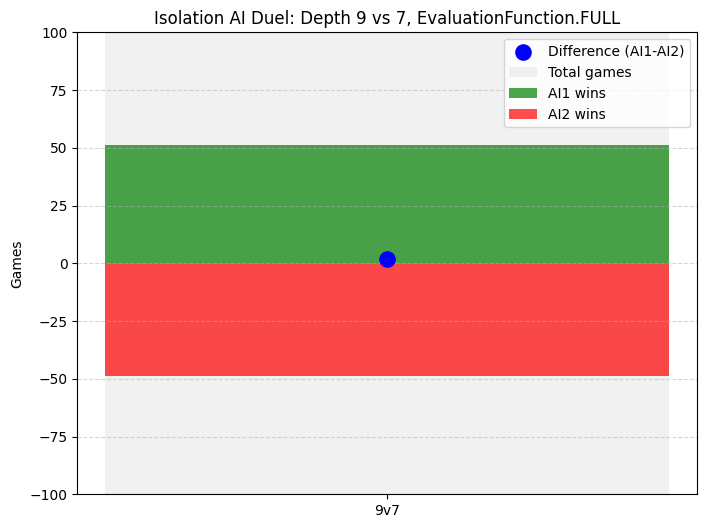

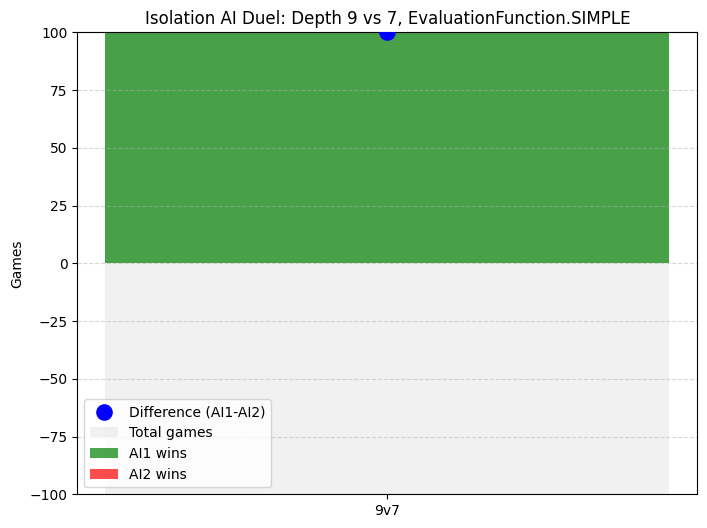

In [9]:
sim = IsolationMultiSim(size=5)
results_full = sim.run_duel((9, 7), n_games=100, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((9, 7), n_games=100, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE);

The next experiment is just a control run to check, if runs with a huge difference in depth will go as expected. This is exactly what happened - in both runs depth 8 won 100% matches against depth 2

Depth 8 vs 2: 100%|██████████| 100/100 [00:08<00:00, 11.80it/s]


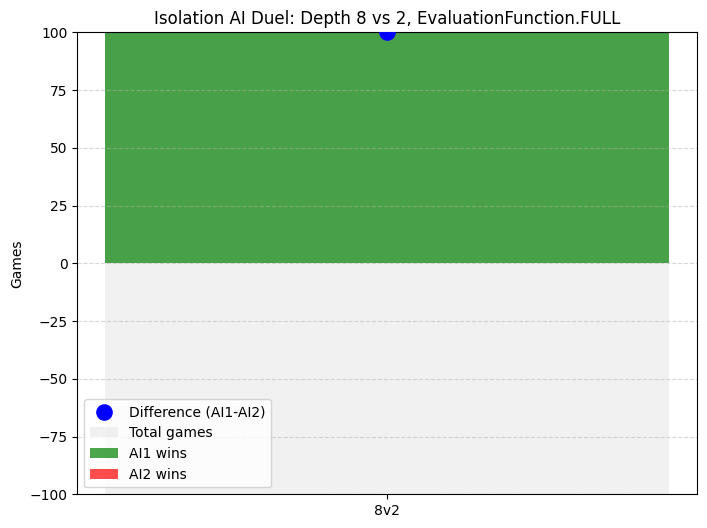

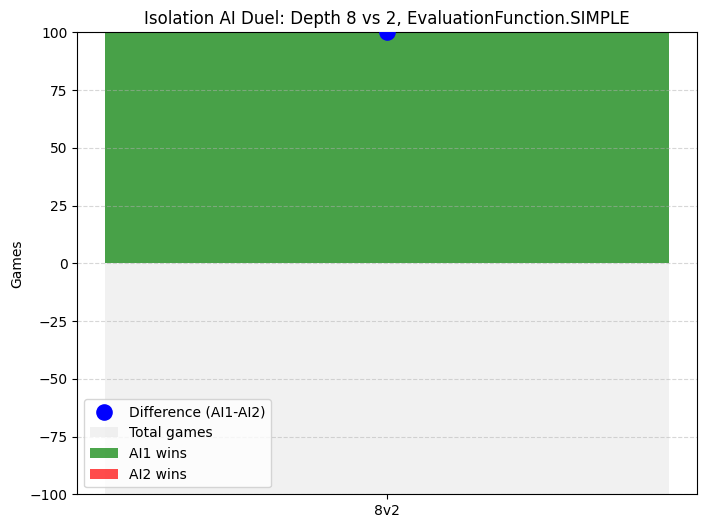

In [10]:
sim = IsolationMultiSim(size=5)
results_full = sim.run_duel((8, 2), n_games=100, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((8, 2), n_games=100, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE)

Now depths 8 and 6 will be tested on board of size 6. This will illustrate, how board size affects the differences between depth efficiency

Depth 8 vs 6: 100%|██████████| 100/100 [00:29<00:00,  3.42it/s]


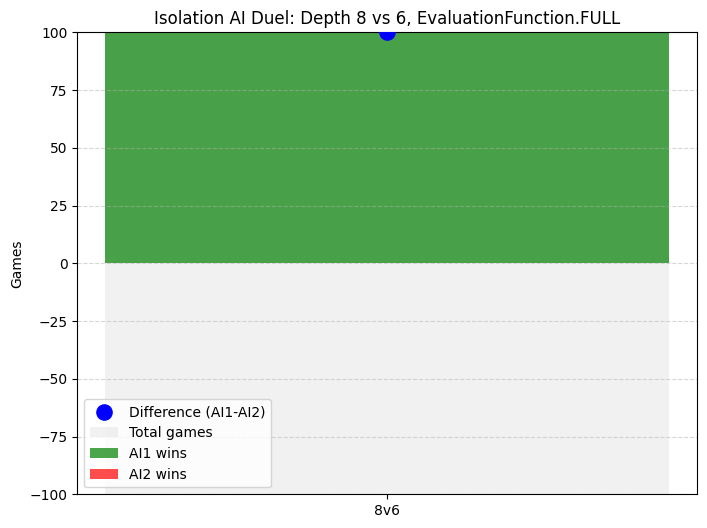

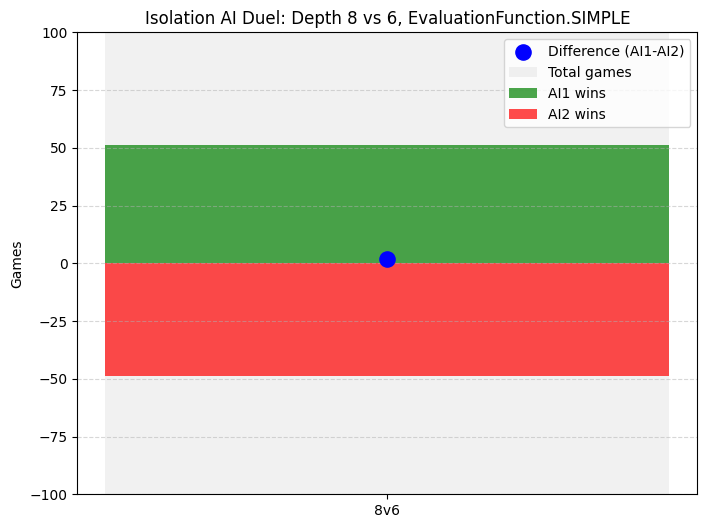

In [11]:
sim = IsolationMultiSim(size=6)
results_full = sim.run_duel((8, 6), n_games=100, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((8, 6), n_games=100, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE);

Finally, let's check how a duel between lower depths looks like. This can show us the true difference between the evaluation algorithms.

Depth 3 vs 1: 100%|██████████| 10/10 [00:00<00:00, 498.81it/s]


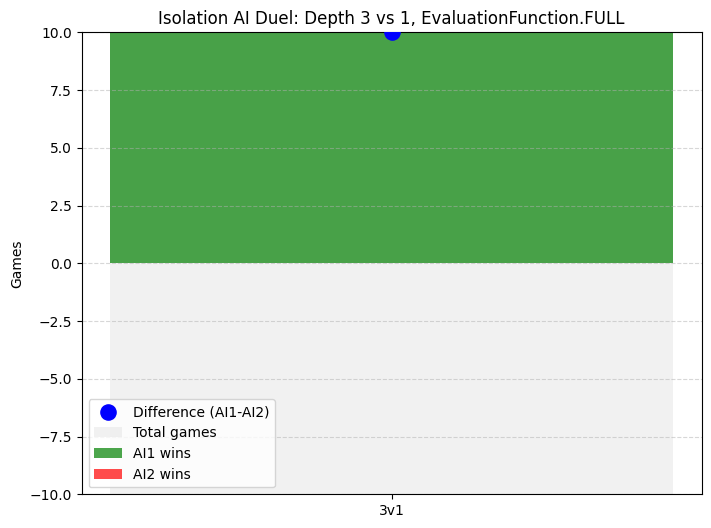

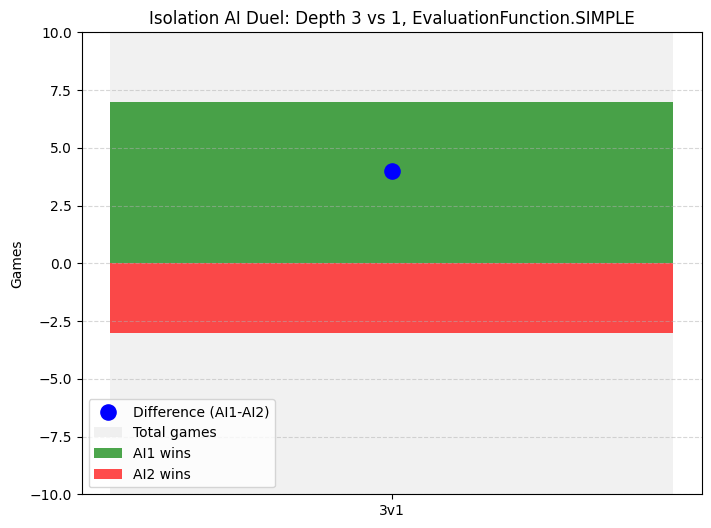

In [12]:
sim = IsolationMultiSim(size=5)
results_full = sim.run_duel((3, 1), n_games=10, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((3, 1), n_games=10, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE);